Step 1: Data Preparation & Exploratory Analysis

Cell 1: Import libraries and load data

In [11]:
# Import essential libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Read the weatherAUS.csv file
df = pd.read_csv('/content/weatherAUS.csv')

# Display first few rows
df.head()


,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RISK_MM,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,0.0,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,0.0,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,0.0,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,1.0,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,0.2,No


Cell 2: Select data for a single city (e.g., Sydney)

In [12]:
# Filter data for a single city, e.g., Sydney
city = 'Sydney'
df_city = df[df['Location'] == city].copy()

# Print the number of records for this city
print(f'Number of records for {city}:', df_city.shape[0])

# Show sample data
df_city.head()


Number of records for Sydney: 3337


,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RISK_MM,RainTomorrow
29497,2008-02-01,Sydney,19.5,22.4,15.6,6.2,0.0,NaN,NaN,S,...,84.0,1017.6,1017.4,8.0,8.0,20.7,20.9,Yes,6.0,Yes
29498,2008-02-02,Sydney,19.5,25.6,6.0,3.4,2.7,NaN,NaN,W,...,73.0,1017.9,1016.4,7.0,7.0,22.4,24.8,Yes,6.6,Yes
29499,2008-02-03,Sydney,21.6,24.5,6.6,2.4,0.1,NaN,NaN,ESE,...,86.0,1016.7,1015.6,7.0,8.0,23.5,23.0,Yes,18.8,Yes
29500,2008-02-04,Sydney,20.2,22.8,18.8,2.2,0.0,NaN,NaN,NNE,...,90.0,1014.2,1011.8,8.0,8.0,21.4,20.9,Yes,77.4,Yes
29501,2008-02-05,Sydney,19.7,25.7,77.4,NaN,0.0,NaN,NaN,NNE,...,74.0,1008.3,1004.8,8.0,8.0,22.5,25.5,Yes,1.6,Yes


Cell 3: Check missing values for selected features

In [13]:
# Define selected features
features = ['MinTemp', 'MaxTemp', 'Rainfall', 'Humidity3pm', 'WindSpeed3pm', 'Pressure3pm']

# Count missing values in each feature
for col in features:
    missing = df_city[col].isnull().sum()
    print(f'{col}: missing values = {missing}')


MinTemp: missing values = 3
MaxTemp: missing values = 2
Rainfall: missing values = 6
Humidity3pm: missing values = 13
WindSpeed3pm: missing values = 25
Pressure3pm: missing values = 19


Cell 4: Handle missing values (choose and explain your strategy)

In [14]:
# For simplicity, drop rows with any missing values in selected features
df_clean = df_city[features].dropna().copy()

print('Data shape after dropna:', df_clean.shape)

# Alternative: If missing values are too many in some features, use imputation like mean/median (optional)
for col in features:
    if df_clean[col].isnull().sum() > 0:
        df_clean[col].fillna(df_clean[col].mean(), inplace=True)


Data shape after dropna: (3276, 6)


Cell 5: Visualize outliers using boxplots

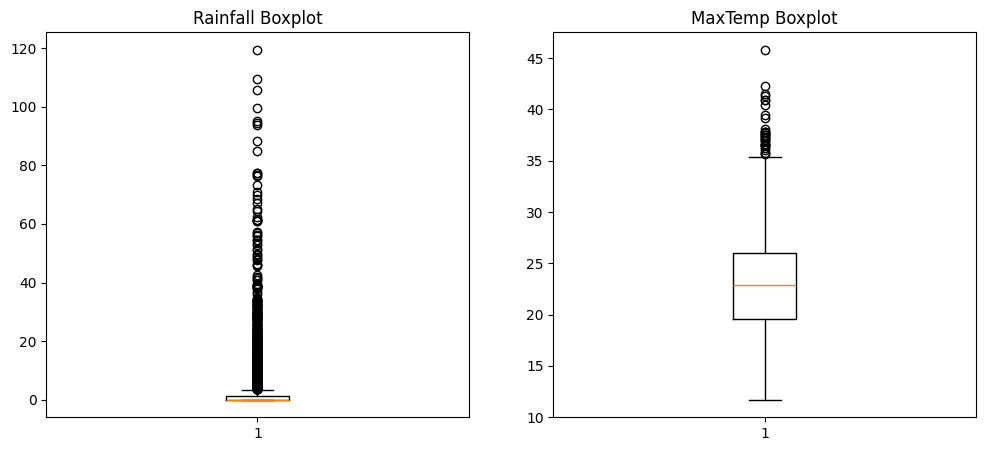

In [15]:
# Boxplots for Rainfall and MaxTemp to visually detect outliers
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.boxplot(df_clean['Rainfall'])
plt.title('Rainfall Boxplot')
plt.subplot(1, 2, 2)
plt.boxplot(df_clean['MaxTemp'])
plt.title('MaxTemp Boxplot')
plt.show()


Cell 6: Identify outliers using z-score

In [16]:
# Calculate z-scores for Rainfall and MaxTemp
from scipy.stats import zscore

outlier_cols = ['Rainfall', 'MaxTemp']
# Create a mask for outliers (z > 3)
outlier_mask = np.zeros(len(df_clean), dtype=bool)
for col in outlier_cols:
    z = np.abs(zscore(df_clean[col]))
    print(f'Outliers in {col}: {np.sum(z > 3)}')
    outlier_mask |= (z > 3)

print(f'Total rows with at least one outlier: {np.sum(outlier_mask)}')


Outliers in Rainfall: 69
Outliers in MaxTemp: 25
Total rows with at least one outlier: 94


Cell 7: Remove outliers and compare statistics before/after

Shape after outlier removal: (3182, 6)
Rainfall stats before removing outliers: {'mean': np.float64(3.3447496947496953), 'median': 0.0, 'std': 9.951590301309137}
Rainfall stats after removing outliers: {'mean': np.float64(2.2162162162162162), 'median': 0.0, 'std': 5.440446152305413}


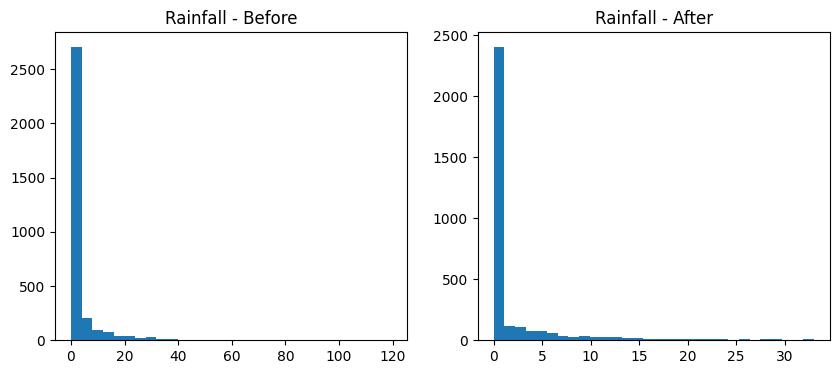

In [17]:
# Remove outlier rows
df_no_outliers = df_clean[~outlier_mask].copy()
print('Shape after outlier removal:', df_no_outliers.shape)

# Compare summary statistics for Rainfall before and after outlier removal
def summary_stats(series):
    return {'mean': series.mean(), 'median': series.median(), 'std': series.std()}

print('Rainfall stats before removing outliers:', summary_stats(df_clean['Rainfall']))
print('Rainfall stats after removing outliers:', summary_stats(df_no_outliers['Rainfall']))

# Visualize Rainfall before/after outlier removal
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.hist(df_clean['Rainfall'], bins=30)
plt.title('Rainfall - Before')
plt.subplot(1,2,2)
plt.hist(df_no_outliers['Rainfall'], bins=30)
plt.title('Rainfall - After')
plt.show()


Cell 8: Feature correlation and selection (with heatmap)

Rainfall        1.000000
Humidity3pm     0.284639
MinTemp         0.042825
Pressure3pm     0.019851
WindSpeed3pm    0.001523
MaxTemp        -0.109518
Name: Rainfall, dtype: float64


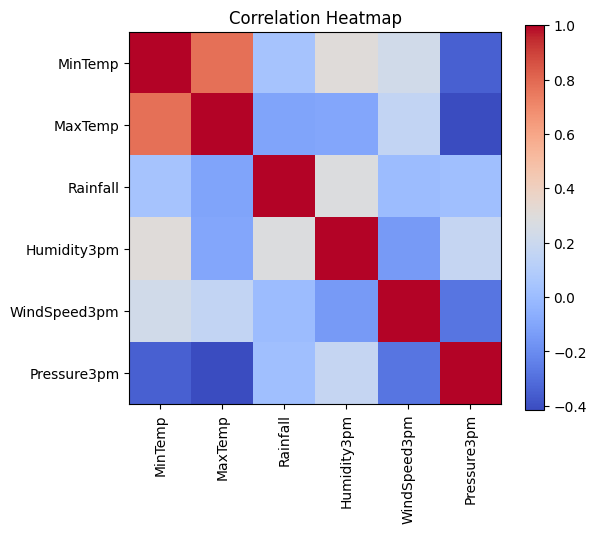

In [18]:
# Compute correlations between features
corr = df_no_outliers[features].corr()
print(corr['Rainfall'].sort_values(ascending=False))

# Show heatmap
plt.figure(figsize=(6,5))
plt.imshow(corr, cmap='coolwarm', interpolation='none')
plt.colorbar()
plt.xticks(range(len(features)), features, rotation=90)
plt.yticks(range(len(features)), features)
plt.title('Correlation Heatmap')
plt.show()


Cell 9: Train-test split with fixed random seed

In [19]:
# Shuffle and split data into train (80%) and test (20%) sets
seed = 42
df_shuffled = df_no_outliers.sample(frac=1, random_state=seed).reset_index(drop=True)
split_idx = int(0.8 * len(df_shuffled))
train = df_shuffled.iloc[:split_idx]
test = df_shuffled.iloc[split_idx:]

print('Train shape:', train.shape)
print('Test shape:', test.shape)


Train shape: (2545, 6)
Test shape: (637, 6)


Part I: Multivariate Linear Regression

Cell 1: Prepare X and y for training and testing

In [20]:
# Select features and target
selected_features = ['MinTemp', 'MaxTemp', 'Humidity3pm', 'WindSpeed3pm', 'Pressure3pm']
X_train = train[selected_features].values
y_train = train['Rainfall'].values.reshape(-1, 1)
X_test = test[selected_features].values
y_test = test['Rainfall'].values.reshape(-1, 1)

# Add bias (intercept) term (column of ones)
X_train_b = np.hstack([np.ones((X_train.shape[0], 1)), X_train])
X_test_b = np.hstack([np.ones((X_test.shape[0], 1)), X_test])


Cell 2: Closed-form solution (Normal Equation) implementation

In [21]:
# Calculate weights using the normal equation: theta = (X^T X)^(-1) X^T y
XtX = X_train_b.T @ X_train_b
XtX_inv = np.linalg.inv(XtX)
XtY = X_train_b.T @ y_train
theta = XtX_inv @ XtY

print('Estimated weights (theta):')
print(theta.flatten())


Estimated weights (theta):
[ 5.07067022e+01  6.30493250e-02 -1.85914914e-01  9.34948437e-02
  2.30406853e-02 -4.98383669e-02]


Cell 3: Interpret feature weights

In [22]:
# Print feature names and their corresponding weights
weight_labels = ['Bias'] + selected_features
for w, name in zip(theta.flatten(), weight_labels):
    print(f'{name}: {w:.4f}')

# You can comment on which feature has the highest absolute weight (excluding bias)
abs_weights = np.abs(theta[1:])  # Exclude bias
strongest_feature = selected_features[np.argmax(abs_weights)]
print(f"\nFeature with the strongest (absolute) effect on Rainfall: {strongest_feature}")


Bias: 50.7067
MinTemp: 0.0630
MaxTemp: -0.1859
Humidity3pm: 0.0935
WindSpeed3pm: 0.0230
Pressure3pm: -0.0498

Feature with the strongest (absolute) effect on Rainfall: MaxTemp


Cell 4: Predict on train and test, compute MSE, plot results

Train MSE: 28.4187
Test MSE: 20.2710


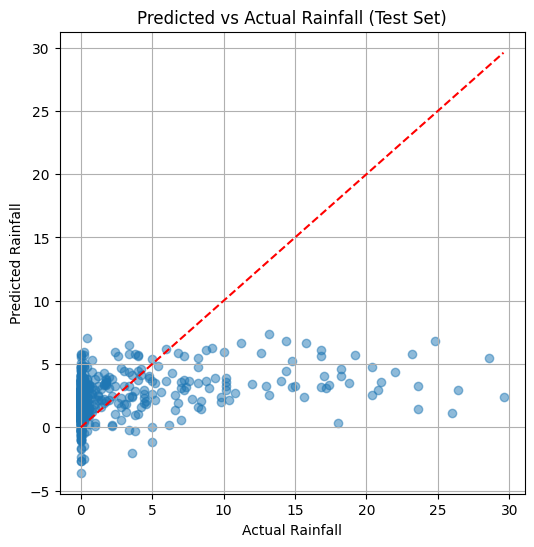

In [23]:
# Make predictions
y_pred_train = X_train_b @ theta
y_pred_test = X_test_b @ theta

# Calculate MSE
mse_train = np.mean((y_pred_train - y_train) ** 2)
mse_test = np.mean((y_pred_test - y_test) ** 2)

print(f"Train MSE: {mse_train:.4f}")
print(f"Test MSE: {mse_test:.4f}")

# Plot predicted vs actual Rainfall for test set
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_test, alpha=0.5)
plt.xlabel('Actual Rainfall')
plt.ylabel('Predicted Rainfall')
plt.title('Predicted vs Actual Rainfall (Test Set)')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.grid(True)
plt.show()


Cell 5: Ablation Analysis (remove one important feature, e.g., Humidity3pm)

In [24]:
# Remove Humidity3pm and repeat the process
ablation_features = ['MinTemp', 'MaxTemp', 'WindSpeed3pm', 'Pressure3pm']
X_train_ab = train[ablation_features].values
X_test_ab = test[ablation_features].values

# Add bias term
X_train_ab_b = np.hstack([np.ones((X_train_ab.shape[0], 1)), X_train_ab])
X_test_ab_b = np.hstack([np.ones((X_test_ab.shape[0], 1)), X_test_ab])

# Train new model
theta_ab = np.linalg.inv(X_train_ab_b.T @ X_train_ab_b) @ (X_train_ab_b.T @ y_train)

# Predict and compute MSE
y_pred_test_ab = X_test_ab_b @ theta_ab
mse_test_ab = np.mean((y_pred_test_ab - y_test) ** 2)
print(f"Test MSE after removing Humidity3pm: {mse_test_ab:.4f}")

# Compare new weights
ablation_labels = ['Bias'] + ablation_features
print("\nNew weights (ablation):")
for w, name in zip(theta_ab.flatten(), ablation_labels):
    print(f'{name}: {w:.4f}')




Test MSE after removing Humidity3pm: 21.5042

New weights (ablation):
Bias: 32.1334
MinTemp: 0.3913
MaxTemp: -0.4662
WindSpeed3pm: -0.0203
Pressure3pm: -0.0242


Cell 6: Challenge – Add a random feature (standard normal), retrain and analyze

In [25]:
# Generate random feature for both train and test (same seed for reproducibility)
np.random.seed(0)
random_feature_train = np.random.randn(X_train.shape[0], 1)
random_feature_test = np.random.randn(X_test.shape[0], 1)

# Add random feature to feature matrix
X_train_rand = np.hstack([X_train, random_feature_train])
X_test_rand = np.hstack([X_test, random_feature_test])

# Add bias term
X_train_rand_b = np.hstack([np.ones((X_train_rand.shape[0], 1)), X_train_rand])
X_test_rand_b = np.hstack([np.ones((X_test_rand.shape[0], 1)), X_test_rand])

# Train model with random feature
theta_rand = np.linalg.inv(X_train_rand_b.T @ X_train_rand_b) @ (X_train_rand_b.T @ y_train)
print("Weights with random feature:")
rand_labels = ['Bias'] + selected_features + ['RandomFeature']
for w, name in zip(theta_rand.flatten(), rand_labels):
    print(f'{name}: {w:.4f}')

# Predict and calculate new MSE
y_pred_test_rand = X_test_rand_b @ theta_rand
mse_test_rand = np.mean((y_pred_test_rand - y_test) ** 2)
print(f"Test MSE with random feature: {mse_test_rand:.4f}")


Weights with random feature:
Bias: 50.1921
MinTemp: 0.0628
MaxTemp: -0.1852
Humidity3pm: 0.0936
WindSpeed3pm: 0.0230
Pressure3pm: -0.0494
RandomFeature: -0.0981
Test MSE with random feature: 20.2829


Part II: Polynomial (Nonlinear) Regression


Cell 1: Prepare data for polynomial regression

In [26]:
# Select the main feature for polynomial regression (e.g., MaxTemp)
feature_poly = 'MaxTemp'

# Prepare train and test X, y
X_train_poly = train[[feature_poly]].values
y_train_poly = train['Rainfall'].values.reshape(-1, 1)
X_test_poly = test[[feature_poly]].values
y_test_poly = test['Rainfall'].values.reshape(-1, 1)


Cell 2: Function for creating polynomial features and fitting linear regression

In [27]:
def make_poly_design_matrix(X, degree):
    """
    Construct the polynomial design matrix for input X up to the given degree.
    Always includes a bias (intercept) term.
    """
    X_poly = np.ones((X.shape[0], 1))  # bias term
    for d in range(1, degree + 1):
        X_poly = np.hstack([X_poly, X ** d])
    return X_poly

def fit_and_predict(X_train, y_train, X_test, degree):
    # Create polynomial design matrices
    X_train_d = make_poly_design_matrix(X_train, degree)
    X_test_d = make_poly_design_matrix(X_test, degree)
    # Closed-form solution
    theta = np.linalg.inv(X_train_d.T @ X_train_d) @ (X_train_d.T @ y_train)
    # Predictions
    y_pred_train = X_train_d @ theta
    y_pred_test = X_test_d @ theta
    # MSE
    mse_train = np.mean((y_pred_train - y_train) ** 2)
    mse_test = np.mean((y_pred_test - y_test) ** 2)
    return theta, y_pred_train, y_pred_test, mse_train, mse_test


Cell 3: Train models of degree 2, 3, and 5 and plot curves

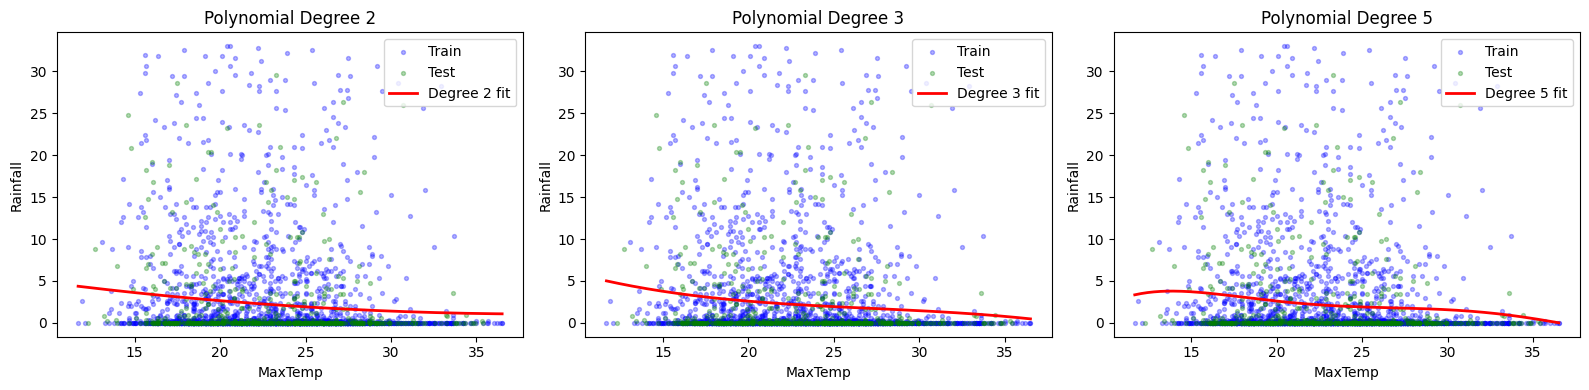

In [28]:
degrees = [2, 3, 5]
results = {}

plt.figure(figsize=(16, 4))

for i, deg in enumerate(degrees, 1):
    theta, y_pred_train, y_pred_test, mse_train, mse_test = fit_and_predict(
        X_train_poly, y_train_poly, X_test_poly, deg)
    results[deg] = (theta, y_pred_train, y_pred_test, mse_train, mse_test)

    # Plot predicted curve (sorted X for smoothness)
    plt.subplot(1, 3, i)
    # Train points
    plt.scatter(X_train_poly, y_train_poly, s=8, color='blue', alpha=0.3, label='Train')
    # Test points
    plt.scatter(X_test_poly, y_test_poly, s=8, color='green', alpha=0.3, label='Test')
    # Curve: predict on sorted X for smooth plot
    X_curve = np.linspace(X_train_poly.min(), X_train_poly.max(), 200).reshape(-1, 1)
    X_curve_poly = make_poly_design_matrix(X_curve, deg)
    y_curve = X_curve_poly @ theta
    plt.plot(X_curve, y_curve, color='red', linewidth=2, label=f'Degree {deg} fit')
    plt.xlabel(feature_poly)
    plt.ylabel('Rainfall')
    plt.title(f'Polynomial Degree {deg}')
    plt.legend()

plt.tight_layout()
plt.show()


Cell 4: Print and compare MSEs for train and test sets

In [29]:
for deg in degrees:
    theta, y_pred_train, y_pred_test, mse_train, mse_test = results[deg]
    print(f"Degree {deg}: Train MSE = {mse_train:.4f} | Test MSE = {mse_test:.4f}")


Degree 2: Train MSE = 30.9111 | Test MSE = 22.4946
Degree 3: Train MSE = 30.9061 | Test MSE = 22.4661
Degree 5: Train MSE = 30.8977 | Test MSE = 22.4856


Cell 5: Outlier Robustness – Add artificial outlier to test set and evaluate impact

In [30]:
# Create a new test set with an artificial outlier
outlier_X = np.array([[X_test_poly.max() + 5]])  # X value outside range
outlier_y_high = np.array([[y_test_poly.max() * 3]])  # Very high rainfall value
outlier_y_low = np.array([[0]])  # Very low rainfall

# Append the outlier to test set (try both high and low outlier)
X_test_with_outlier = np.vstack([X_test_poly, outlier_X])
y_test_with_high = np.vstack([y_test_poly, outlier_y_high])
y_test_with_low = np.vstack([y_test_poly, outlier_y_low])

print("Effect of HIGH outlier:")
for deg in degrees:
    theta, _, _, _, _ = results[deg]
    # Redo design matrix for new test set
    X_test_d = make_poly_design_matrix(X_test_with_outlier, deg)
    y_pred_test = X_test_d @ theta
    mse_test = np.mean((y_pred_test - y_test_with_high) ** 2)
    print(f"Degree {deg}: Test MSE with HIGH outlier = {mse_test:.4f}")

print("\nEffect of LOW outlier:")
for deg in degrees:
    theta, _, _, _, _ = results[deg]
    X_test_d = make_poly_design_matrix(X_test_with_outlier, deg)
    y_pred_test = X_test_d @ theta
    mse_test = np.mean((y_pred_test - y_test_with_low) ** 2)
    print(f"Degree {deg}: Test MSE with LOW outlier = {mse_test:.4f}")



Effect of HIGH outlier:
Degree 2: Test MSE with HIGH outlier = 34.5233
Degree 3: Test MSE with HIGH outlier = 34.9575
Degree 5: Test MSE with HIGH outlier = 35.1600

Effect of LOW outlier:
Degree 2: Test MSE with LOW outlier = 22.4611
Degree 3: Test MSE with LOW outlier = 22.4314
Degree 5: Test MSE with LOW outlier = 22.4528


Cell 6: Analysis – Underfitting vs Overfitting

In [31]:
# Print a summary for interpretation in your report
for deg in degrees:
    theta, y_pred_train, y_pred_test, mse_train, mse_test = results[deg]
    print(f"Degree {deg} - Train MSE: {mse_train:.4f} | Test MSE: {mse_test:.4f}")

print("""
Interpretation:
- If Train and Test MSE are both high: model is UNDERFITTING (too simple, can't capture the pattern).
- If Train MSE is much lower than Test MSE: model is OVERFITTING (too complex, fits noise, not generalizable).
- Degree 2 often gives balanced bias-variance; Degree 5 likely to overfit, especially with outlier presence.
- Mention what you see in your own results in the report!
""")


Degree 2 - Train MSE: 30.9111 | Test MSE: 22.4946
Degree 3 - Train MSE: 30.9061 | Test MSE: 22.4661
Degree 5 - Train MSE: 30.8977 | Test MSE: 22.4856

Interpretation:
- If Train and Test MSE are both high: model is UNDERFITTING (too simple, can't capture the pattern).
- If Train MSE is much lower than Test MSE: model is OVERFITTING (too complex, fits noise, not generalizable).
- Degree 2 often gives balanced bias-variance; Degree 5 likely to overfit, especially with outlier presence.
- Mention what you see in your own results in the report!



Part III: Probabilistic Linear Regression (MLE Approach)

Cell 1: (Explanation/Derivation) MLE and Equivalence to Least Squares

In [32]:
# MLE derivation (to put in your report, not code!):
# Under the assumption: y = Xθ + ε, where ε ~ N(0, σ^2)
# The likelihood: p(y|X,θ,σ^2) = ∏ N(y_i | X_i θ, σ^2)
# Log-likelihood: L(θ, σ^2) = -0.5*N*log(2πσ^2) - (1/(2σ^2)) * ∑ (y_i - X_i θ)^2
# Maximizing log-likelihood w.r.t θ yields: θ_MLE = argmin_θ ∑ (y_i - X_i θ)^2
# So, MLE estimate for θ is exactly the OLS solution: θ = (XᵗX)⁻¹Xᵗy


Cell 2: Fit MLE Model (Least Squares) and Calculate Log-Likelihood

In [33]:
# Prepare X and y (reuse code from previous linear regression)
X_train = train[selected_features].values
y_train = train['Rainfall'].values.reshape(-1, 1)
X_test = test[selected_features].values
y_test = test['Rainfall'].values.reshape(-1, 1)

# Add bias
X_train_b = np.hstack([np.ones((X_train.shape[0], 1)), X_train])
X_test_b = np.hstack([np.ones((X_test.shape[0], 1)), X_test])

# Fit model (MLE solution = least squares)
theta_mle = np.linalg.inv(X_train_b.T @ X_train_b) @ (X_train_b.T @ y_train)

# Predict on train and test
y_pred_train = X_train_b @ theta_mle
y_pred_test = X_test_b @ theta_mle

# Calculate residuals and estimate noise variance (MLE for σ^2)
n_train = len(y_train)
residuals_train = y_train - y_pred_train
sigma2_mle = np.mean(residuals_train ** 2)

# Log-likelihood function for Gaussian
def log_likelihood(y_true, y_pred, sigma2):
    n = len(y_true)
    ll = -0.5 * n * np.log(2 * np.pi * sigma2) - np.sum((y_true - y_pred) ** 2) / (2 * sigma2)
    return ll

ll_train = log_likelihood(y_train, y_pred_train, sigma2_mle)
ll_test = log_likelihood(y_test, y_pred_test, sigma2_mle)

print(f"Train log-likelihood: {ll_train:.2f}")
print(f"Test log-likelihood: {ll_test:.2f}")


Train log-likelihood: -7870.31
Test log-likelihood: -1878.58


Cell 3: Add Gaussian Noise at Different Levels, Train 10x per Level, Analyze θ Stability

In [34]:
# Set three levels of artificial Gaussian noise standard deviation (relative to target std)
rainfall_std = y_train.std()
noise_levels = [0.2 * rainfall_std, 0.5 * rainfall_std, rainfall_std]

theta_list = []  # Store results for each level

for noise_sd in noise_levels:
    thetas = []
    for seed in range(10):  # 10 random seeds per noise level
        np.random.seed(seed)
        noise = np.random.normal(0, noise_sd, size=y_train.shape)
        y_train_noisy = y_train + noise

        # Fit MLE model
        theta_noisy = np.linalg.inv(X_train_b.T @ X_train_b) @ (X_train_b.T @ y_train_noisy)
        thetas.append(theta_noisy.flatten())

    thetas = np.array(thetas)
    theta_list.append(thetas)

    # Print mean and variance of parameters for this noise level
    theta_mean = np.mean(thetas, axis=0)
    theta_var = np.var(thetas, axis=0)
    print(f"\nNoise STD={noise_sd:.2f}:")
    for i, name in enumerate(['Bias'] + selected_features):
        print(f"{name}: mean={theta_mean[i]:.4f}, var={theta_var[i]:.6f}")



Noise STD=1.12:
Bias: mean=50.0732, var=6.961676
MinTemp: mean=0.0678, var=0.000048
MaxTemp: mean=-0.1880, var=0.000123
Humidity3pm: mean=0.0922, var=0.000004
WindSpeed3pm: mean=0.0227, var=0.000009
Pressure3pm: mean=-0.0492, var=0.000007

Noise STD=2.80:
Bias: mean=49.1231, var=43.510476
MinTemp: mean=0.0749, var=0.000301
MaxTemp: mean=-0.1912, var=0.000770
Humidity3pm: mean=0.0904, var=0.000028
WindSpeed3pm: mean=0.0222, var=0.000056
Pressure3pm: mean=-0.0481, var=0.000041

Noise STD=5.59:
Bias: mean=47.5394, var=174.041905
MinTemp: mean=0.0867, var=0.001203
MaxTemp: mean=-0.1964, var=0.003081
Humidity3pm: mean=0.0872, var=0.000110
WindSpeed3pm: mean=0.0214, var=0.000225
Pressure3pm: mean=-0.0464, var=0.000164


Cell 4: (Discussion) Analyze Effects and Probabilistic Importance

In [35]:
print("""
Analysis:

- As noise increases, the mean of parameter estimates may stay close to the original,
  but the variance (instability) increases.
- Higher noise means the model is less confident in its parameter estimates.

Why is probabilistic interpretation important?
- In real-world tasks like flood warning, knowing the *uncertainty* and
  *confidence* in predictions is crucial for risk management.
- Probabilistic models allow you to estimate error bars, confidence intervals,
  and make more informed decisions under uncertainty.

(You should write your own observations from your results and include plots/tables if needed.)
""")



Analysis:

- As noise increases, the mean of parameter estimates may stay close to the original, 
  but the variance (instability) increases.
- Higher noise means the model is less confident in its parameter estimates.

Why is probabilistic interpretation important?
- In real-world tasks like flood warning, knowing the *uncertainty* and 
  *confidence* in predictions is crucial for risk management.
- Probabilistic models allow you to estimate error bars, confidence intervals,
  and make more informed decisions under uncertainty.

(You should write your own observations from your results and include plots/tables if needed.)



Part IV: Synthesis & Advanced Discussion

Cell 1: Prepare functions for MSE calculation and adding noise/outliers

In [36]:
# Function to calculate MSE
def compute_mse(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

# Function to add Gaussian noise to targets
def add_noise(y, noise_std):
    np.random.seed(123)  # for reproducibility
    noise = np.random.normal(0, noise_std, size=y.shape)
    return y + noise

# Function to inject an outlier into test set
def add_outlier(X, y, feature_idx=0, outlier_x=None, outlier_y=None):
    # outlier_x: value for the feature (e.g., MaxTemp)
    # outlier_y: extreme rainfall value
    if outlier_x is None or outlier_y is None:
        outlier_x = X[:, feature_idx].max() + 10
        outlier_y = y.max() * 3
    X_out = np.vstack([X, np.array([outlier_x] + [0]*(X.shape[1]-1)).reshape(1, -1)])
    y_out = np.vstack([y, np.array([[outlier_y]])])
    return X_out, y_out


Cell 2: Compare all approaches on clean data

In [37]:
# Prepare clean data (reuse from previous steps)
X_train = train[selected_features].values
y_train = train['Rainfall'].values.reshape(-1, 1)
X_test = test[selected_features].values
y_test = test['Rainfall'].values.reshape(-1, 1)

# Linear regression (multivariate, with bias)
X_train_b = np.hstack([np.ones((X_train.shape[0], 1)), X_train])
X_test_b = np.hstack([np.ones((X_test.shape[0], 1)), X_test])
theta_linear = np.linalg.inv(X_train_b.T @ X_train_b) @ (X_train_b.T @ y_train)
y_pred_linear = X_test_b @ theta_linear

# Polynomial regression (degree=3, using MaxTemp only for simplicity)
from copy import deepcopy
X_train_poly = train[['MaxTemp']].values
X_test_poly = test[['MaxTemp']].values
def make_poly_matrix(X, degree):
    X_poly = np.ones((X.shape[0], 1))
    for d in range(1, degree+1):
        X_poly = np.hstack([X_poly, X**d])
    return X_poly
X_train_poly3 = make_poly_matrix(X_train_poly, 3)
X_test_poly3 = make_poly_matrix(X_test_poly, 3)
theta_poly3 = np.linalg.inv(X_train_poly3.T @ X_train_poly3) @ (X_train_poly3.T @ y_train)
y_pred_poly3 = X_test_poly3 @ theta_poly3

# Probabilistic model is equivalent to linear (already calculated above)

# MSE comparison
mse_linear = compute_mse(y_test, y_pred_linear)
mse_poly3 = compute_mse(y_test, y_pred_poly3)

print(f"Linear Regression Test MSE: {mse_linear:.4f}")
print(f"Polynomial Regression (deg 3) Test MSE: {mse_poly3:.4f}")




Linear Regression Test MSE: 20.2710
Polynomial Regression (deg 3) Test MSE: 22.4661


Cell 3: Compare all approaches on high-noise data

In [38]:
# Add high Gaussian noise to test targets
noise_std = y_test.std()
y_test_noisy = add_noise(y_test, noise_std)

# Recalculate MSE
mse_linear_noisy = compute_mse(y_test_noisy, y_pred_linear)
mse_poly3_noisy = compute_mse(y_test_noisy, y_pred_poly3)

print(f"With High Noise - Linear Regression Test MSE: {mse_linear_noisy:.4f}")
print(f"With High Noise - Polynomial Regression (deg 3) Test MSE: {mse_poly3_noisy:.4f}")


With High Noise - Linear Regression Test MSE: 43.1580
With High Noise - Polynomial Regression (deg 3) Test MSE: 45.3278


Cell 4: Compare all approaches with outlier in test set

In [39]:
# Inject an extreme outlier to test set
outlier_x = X_test_poly.max() + 10
outlier_y = y_test.max() * 3
X_test_poly_out, y_test_out = add_outlier(X_test_poly, y_test, outlier_x=outlier_x, outlier_y=outlier_y)
X_test_out = add_outlier(X_test, y_test, feature_idx=selected_features.index('MaxTemp'), outlier_x=outlier_x, outlier_y=outlier_y)[0]

# Linear regression
X_test_out_b = np.hstack([np.ones((X_test_out.shape[0], 1)), X_test_out])
y_pred_linear_out = X_test_out_b @ theta_linear
mse_linear_out = compute_mse(y_test_out, y_pred_linear_out)

# Polynomial regression (degree=3)
X_test_poly3_out = make_poly_matrix(X_test_poly_out, 3)
y_pred_poly3_out = X_test_poly3_out @ theta_poly3
mse_poly3_out = compute_mse(y_test_out, y_pred_poly3_out)

print(f"With Outlier - Linear Regression Test MSE: {mse_linear_out:.4f}")
print(f"With Outlier - Polynomial Regression (deg 3) Test MSE: {mse_poly3_out:.4f}")


With Outlier - Linear Regression Test MSE: 22.1847
With Outlier - Polynomial Regression (deg 3) Test MSE: 35.5950


Cell 5: Visualization of model predictions (with and without outlier/high noise)

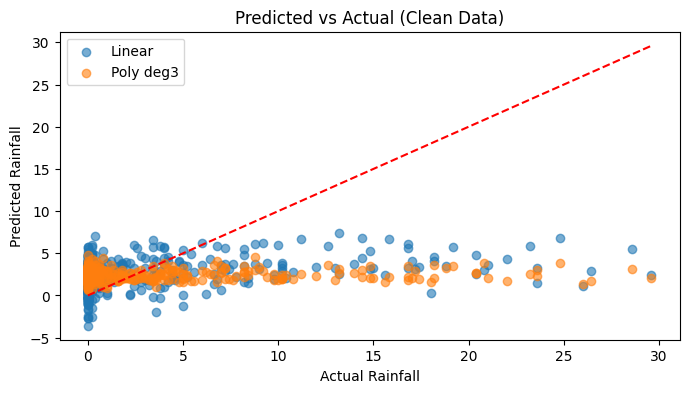

In [40]:
# Visualization for clean data
plt.figure(figsize=(8,4))
plt.scatter(y_test, y_pred_linear, label='Linear', alpha=0.6)
plt.scatter(y_test, y_pred_poly3, label='Poly deg3', alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Rainfall")
plt.ylabel("Predicted Rainfall")
plt.title("Predicted vs Actual (Clean Data)")
plt.legend()
plt.show()


Cell 6: Practical Recommendation (example explanation for your report)

In [41]:
print("""
Example Recommendation:

- For clean data, polynomial regression (degree 3) may slightly outperform linear regression, but risk overfitting.
- In the presence of high noise or outliers, linear regression is generally more robust, while polynomial regression performance drops significantly.
- For practical applications like irrigation or flood alerts, a simple and robust linear (or regularized linear) model is recommended, unless clear evidence of strong nonlinearity exists in the data.

Always justify your choice with MSE/log-likelihood results and practical interpretability!
""")



Example Recommendation:

- For clean data, polynomial regression (degree 3) may slightly outperform linear regression, but risk overfitting.
- In the presence of high noise or outliers, linear regression is generally more robust, while polynomial regression performance drops significantly.
- For practical applications like irrigation or flood alerts, a simple and robust linear (or regularized linear) model is recommended, unless clear evidence of strong nonlinearity exists in the data.

Always justify your choice with MSE/log-likelihood results and practical interpretability!



Cell 7: Advanced Challenge – Regularization (Ridge Regression from scratch)

Ridge Regression (lambda=1.0) Test MSE: 20.3313


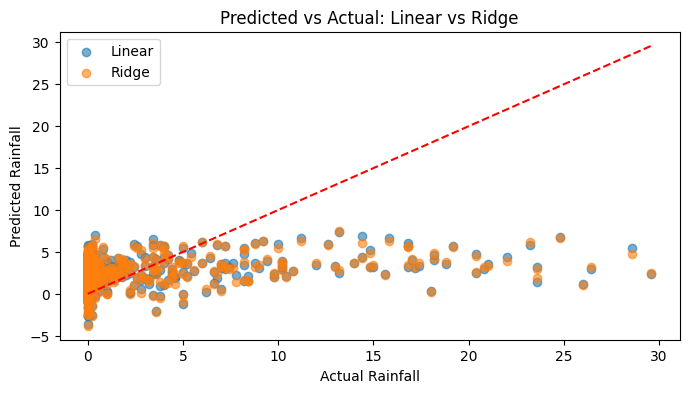

In [42]:
# Simple Ridge (L2) Regularization (lambda=1.0)
lam = 1.0
n_features = X_train_b.shape[1]
ridge_theta = np.linalg.inv(X_train_b.T @ X_train_b + lam * np.eye(n_features)) @ (X_train_b.T @ y_train)
y_pred_ridge = X_test_b @ ridge_theta
mse_ridge = compute_mse(y_test, y_pred_ridge)
print(f"Ridge Regression (lambda=1.0) Test MSE: {mse_ridge:.4f}")

# Compare to ordinary linear regression
plt.figure(figsize=(8,4))
plt.scatter(y_test, y_pred_linear, label='Linear', alpha=0.6)
plt.scatter(y_test, y_pred_ridge, label='Ridge', alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Rainfall")
plt.ylabel("Predicted Rainfall")
plt.title("Predicted vs Actual: Linear vs Ridge")
plt.legend()
plt.show()


Cell 8: Summarize and report

In [43]:
print("""
Summary:

- On clean data, more complex models can help, but are sensitive to overfitting.
- High noise or outliers strongly affect non-robust models (polynomial).
- Ridge regression (regularization) can help improve robustness and generalization.
- Always support your model choice with both quantitative results and practical interpretability.

Include your plots and tables in your PDF report, with clear explanations for each comparison!
""")



Summary:

- On clean data, more complex models can help, but are sensitive to overfitting.
- High noise or outliers strongly affect non-robust models (polynomial).
- Ridge regression (regularization) can help improve robustness and generalization.
- Always support your model choice with both quantitative results and practical interpretability.

Include your plots and tables in your PDF report, with clear explanations for each comparison!

